# CHSH Game

Bell's Theorem demonstrated that the properties of entangled quantum states could not be a consequence of local hidden variables, meaning that at least one of the following assumptions could not hold: locality, that a measurement's outcome isn't determined by a distant measurement, or realism, that the outcome is governed by predetermined, perhaps unknown, variables rather than created through measurement.

This is experimentally testable through the CHSH inequality, a form of Bell's inequality. Consider a game a referee gives Alice and Bob each a bit, $x$ and $y$, and according to some strategy based on the bit received, they each send a bit back to the referee $a(x)$ and $b(y)$ respectively. They win the round if $a(x) \oplus b(y) = xy$. It can be shown that classically the best possible strategy wins at best $75\%$ of the time. Thus, $75\%$ is the upper bound for winning according to a local hidden variable theory. By contrast, a quantum strategy in which prior to the referee sending bits $x$ and $y$, Alice and Bob already share entangled qubits, can achieve a winning probability of $\cos^2(\pi/8)$, about $85\%$, the Tsirelson bound. This thus violates local realism.

In this notebook I build the circuit for the quantum strategy, simulate the quantum prediction, and determine the win rate over many rounds.

In [86]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from IPython.display import display
import numpy as np

In [87]:
def make_chsh_circuit():
    qc = QuantumCircuit(4)
    alice, alice_ref, bob, bob_ref = 0, 1, 2, 3
    #prepare alice and bob share entanglement state
    qc.h(alice)
    qc.cx(alice, bob)
    qc.rx(-np.pi/4, alice) #alice measurement basis in y-z plane on Bloch
    #referee sends his qubits as |+>
    qc.h(alice_ref)
    qc.h(bob_ref)
    #csx to measure controlled on referee bit
    qc.csx(alice_ref, alice)
    qc.csx(bob_ref, bob)
    #alice and bob basis pair 45 degrees apart, chsh optimal
    qc.measure_all()
    return qc

In [88]:
def parse_bitstring(bitstring):
    bits = bitstring[::-1] #qiskit reverses
    #ordering because circuit defined alice, alice_ref, bob, bob_ref
    a = int(bits[0])
    b = int(bits[2])
    x = int(bits[1])
    y = int(bits[3])
    return a, b, x, y


In [89]:
def run_game(shots = 1000):
    circuit = make_chsh_circuit()
    print('Circuit:')
    display(circuit.draw('mpl'))

    #run simulations
    print()
    print('Simulating {} repetitions...'.format(shots))
    sampler = StatevectorSampler(default_shots=shots)
    result = sampler.run([circuit]).result()
    counts = result[0].data.meas.get_counts()

    wins = 0
    total = 0
    for bitstring, count in counts.items():
        a, b, x, y = parse_bitstring(bitstring)
        #condition a XOR b == x AND y
        if (a ^ b) == (x & y):
            wins += count
        total += count
    return wins/total

Circuit:


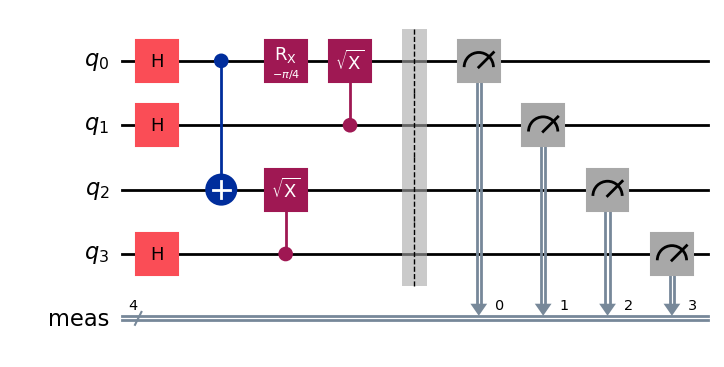


Simulating 1000 repetitions...
Win probability: 0.849
Classical bound: 0.750
Tsirelson bound: 0.854


In [90]:
probability = run_game(1000)
print(f'Win probability: {probability:.3f}')
print("Classical bound: 0.750")
print("Tsirelson bound: 0.854")